In [ ]:
import eli5
from eli5.sklearn import PermutationImportance
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, confusion_matrix, classification_report, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. EXPLORATORY DATA ANALYSIS & PREPARATION

### 1.1. Load the dataset

In [3]:
df = pd.read_csv('data/bar_pass_prediction.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


### 1.2. Initial data visualization and characterization

In [129]:

print("--- First 5 rows of the dataset ---")
print(df.head())

print("\n--- Dataset Information ---")
print(df.info())

print("\n--- Statistical Summary ---")
display(df.describe(include='all'))

--- First 5 rows of the dataset ---
   decile1b  decile3  ID  decile1  sex  race  cluster  lsat  ugpa  zfygpa  \
0      10.0     10.0   2     10.0  1.0   7.0      1.0  44.0   3.5    1.33   
1       5.0      4.0   3      5.0  1.0   7.0      2.0  29.0   3.5   -0.11   
2       3.0      2.0  36      3.0  2.0   7.0      3.0  36.0   3.5   -0.64   
3       7.0      4.0  52      7.0  2.0   7.0      3.0  39.0   3.5    0.34   
4       9.0      8.0  55      9.0  2.0   7.0      4.0  48.0   3.5    1.02   

   ...  hisp pass_bar                bar bar_passed  tier   index6040  \
0  ...     0        1  a Passed 1st time       True   4.0  886.842082   
1  ...     0        1  a Passed 1st time       True   2.0  649.999987   
2  ...     0        1  a Passed 1st time       True   3.0  760.526298   
3  ...     0        1  a Passed 1st time       True   3.0  807.894717   
4  ...     0        1  a Passed 1st time       True   5.0  949.999974   

     indxgrp   indxgrp2  dnn_bar_pass_prediction  gpa  
0     

,decile1b,decile3,ID,decile1,sex,race,cluster,lsat,ugpa,zfygpa,...,hisp,pass_bar,bar,bar_passed,tier,index6040,indxgrp,indxgrp2,dnn_bar_pass_prediction,gpa
count,20803.000000,20803.000000,22407.000000,21315.000000,22402.000000,22391.000000,22311.000000,22407.000000,22407.000000,21423.000000,...,22407.000000,22407.000000,22407,22407,22311.000000,22407.000000,22407,22407,22407.000000,22407.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4,2,NaN,NaN,7,9,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,a Passed 1st time,True,NaN,NaN,g 700+,i 820+,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,19839,21237,NaN,NaN,15272,5241,NaN,NaN
mean,5.528481,5.525934,13768.253537,5.708234,1.561378,6.458354,2.817355,36.767907,3.215451,0.086068,...,0.004686,0.947829,NaN,NaN,3.768814,744.196203,NaN,NaN,0.980682,3.215451
std,2.854800,2.851286,7929.063192,2.783098,0.496229,1.433301,1.384079,5.463248,0.404073,0.928683,...,0.068296,0.222377,NaN,NaN,1.179375,103.770570,NaN,NaN,0.022594,0.404073
min,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,11.000000,1.500000,-3.350000,...,0.000000,0.000000,NaN,NaN,1.000000,288.947365,NaN,NaN,0.330740,1.500000
25%,3.000000,3.000000,6926.500000,3.000000,1.000000,7.000000,1.000000,33.000000,3.000000,-0.560000,...,0.000000,1.000000,NaN,NaN,3.000000,678.947352,NaN,NaN,0.971071,3.000000
50%,6.000000,6.000000,13772.000000,6.000000,2.000000,7.000000,3.000000,37.000000,3.200000,0.080000,...,0.000000,1.000000,NaN,NaN,4.000000,747.894717,NaN,NaN,0.983144,3.200000
75%,8.000000,8.000000,20628.500000,8.000000,2.000000,7.000000,4.000000,41.000000,3.500000,0.740000,...,0.000000,1.000000,NaN,NaN,5.000000,815.263136,NaN,NaN,0.996526,3.500000


### 1.3. Data cleanup

In [38]:
# Select columns to be used
columns_of_interest = ['race1', 'male', 'fam_inc', 'tier', 'ugpa', 'pass_bar']
# Drop rows with null or empty values from columns of interest
df = df[columns_of_interest].dropna()

clean_df = df[['ugpa', 'pass_bar']] 
clean_df["race"] = df["race1"] # rename 'race1' to 'race' -> improve readability of categoric features
clean_df["male"] = df["male"].astype(int)
clean_df["fam_inc"] = df["fam_inc"].astype(int)
clean_df["tier"] = df["tier"].astype(int)

# One-Hot enconding on categoric features ('race')
df_encoded = pd.get_dummies(clean_df, columns=['race'], drop_first=False, dtype=int)
# drop race_white column as only adds noise
df_encoded = df_encoded.drop(columns=["race_white"])

print(df_encoded.info())

<class 'pandas.DataFrame'>
Index: 22013 entries, 0 to 22406
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ugpa        22013 non-null  float64
 1   pass_bar    22013 non-null  int64  
 2   male        22013 non-null  int64  
 3   fam_inc     22013 non-null  int64  
 4   tier        22013 non-null  int64  
 5   race_asian  22013 non-null  int64  
 6   race_black  22013 non-null  int64  
 7   race_hisp   22013 non-null  int64  
 8   race_other  22013 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 1.7 MB
None


### 1.3. Data distribution

#### Ordinal and Continuous distributions

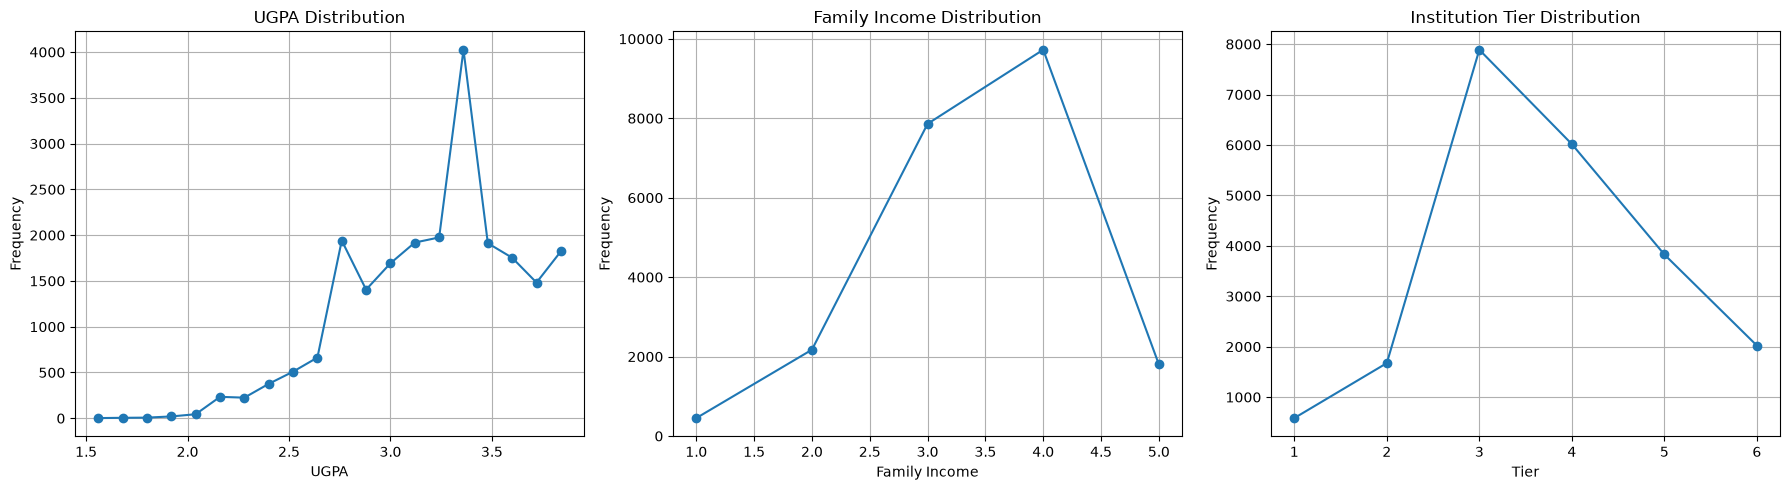

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ======================================
# UGPA Distribution
# ======================================

counts, bins = np.histogram(df["ugpa"], bins=20)

centers = (bins[:-1] + bins[1:]) / 2

axes[0].plot(centers, counts, marker='o')

axes[0].set_title("UGPA Distribution")
axes[0].set_xlabel("UGPA")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# ======================================
# Family Income Distribution
# ======================================

fam_counts = df["fam_inc"].value_counts().sort_index()

axes[1].plot(
    fam_counts.index,
    fam_counts.values,
    marker='o'
)

axes[1].set_title("Family Income Distribution")
axes[1].set_xlabel("Family Income")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

# ======================================
# Tier Distribution
# ======================================

tier_counts = df["tier"].value_counts().sort_index()

axes[2].plot(
    tier_counts.index,
    tier_counts.values,
    marker='o'
)

axes[2].set_title("Institution Tier Distribution")
axes[2].set_xlabel("Tier")
axes[2].set_ylabel("Frequency")
axes[2].grid(True)

plt.tight_layout()

plt.savefig("figures/distributions_numerical_variables.png", dpi=300)

plt.show()

#### Categoric and Binary distributions

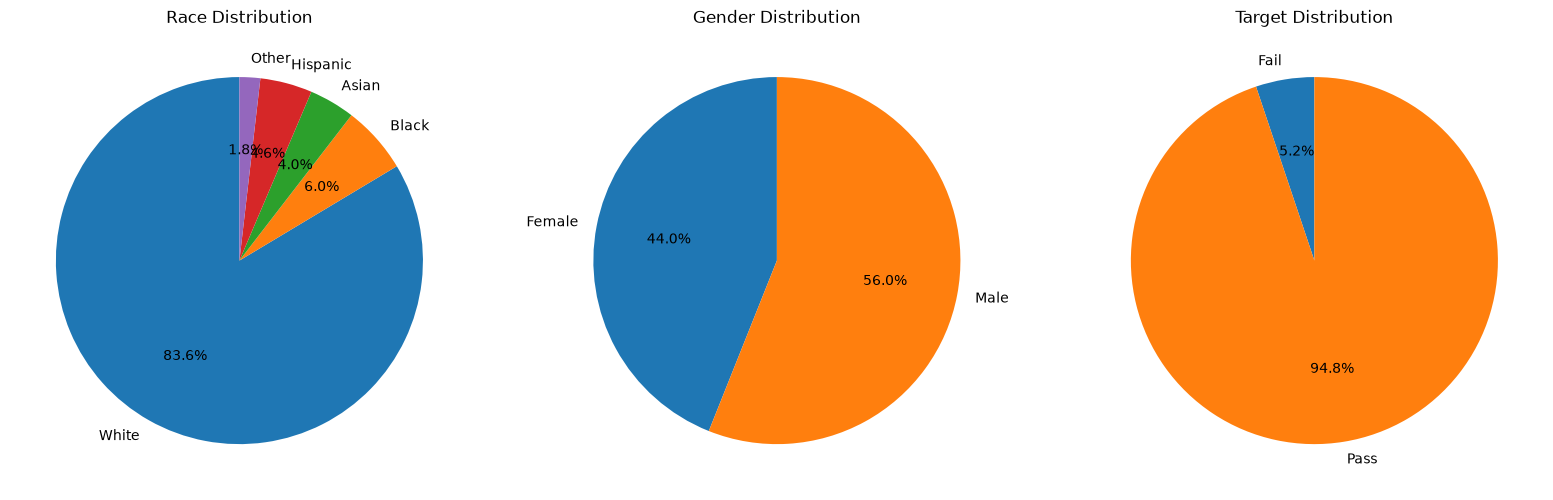

In [ ]:
# ==========================
# Race Distribution
# ==========================

white = len(df_encoded) - (
    df_encoded["race_asian"] +
    df_encoded["race_black"] +
    df_encoded["race_hisp"] +
    df_encoded["race_other"]
).sum()

race_sizes = [
    white,
    df_encoded["race_black"].sum(),
    df_encoded["race_asian"].sum(),
    df_encoded["race_hisp"].sum(),
    df_encoded["race_other"].sum()
]

race_labels = [
    "White",
    "Black",
    "Asian",
    "Hispanic",
    "Other"
]

# ==========================
# Gender Distribution
# ==========================

gender_sizes = [
    (df_encoded["male"] == 0).sum(),
    (df_encoded["male"] == 1).sum()
]

gender_labels = [
    "Female",
    "Male"
]

# ==========================
# Target Distribution
# ==========================

target_sizes = [
    (df_encoded["pass_bar"] == 0).sum(),
    (df_encoded["pass_bar"] == 1).sum()
]

target_labels = [
    "Fail",
    "Pass"
]

# ==========================
# Plot
# ==========================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Race
axes[0].pie(
    race_sizes,
    labels=race_labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title("Race Distribution")

# Gender
axes[1].pie(
    gender_sizes,
    labels=gender_labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title("Gender Distribution")

# Target
axes[2].pie(
    target_sizes,
    labels=target_labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[2].set_title("Target Distribution")

plt.tight_layout()

plt.savefig("figures/distributions_categoric_variable.png", dpi=300)

plt.show()

### 1.4. Correlation matrix (Bivariate analysis)

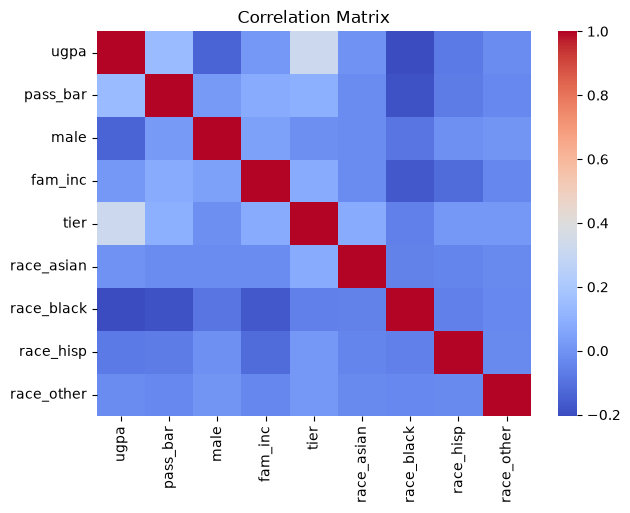

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig("figures/variables_correlation_matrix.png")
plt.show()

### 1.5. Train/Test data split and feature scaling

In [6]:
X = df_encoded.drop(columns=['pass_bar'])
y = df_encoded['pass_bar']

# Splitting the data (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = list(X_train.columns)

O uso do `StandardScaler` é um passo fundamental no pré-processamento de dados em Machine Learning.

Em termos simples, ele **padroniza as tuas variáveis (features)** para que todas fiquem na mesma escala, garantindo que tenham uma média de 0 e um desvio padrão de 1. A fórmula matemática aplicada a cada valor é $z = \frac{x - \mu}{\sigma}$ (onde $\mu$ é a média e $\sigma$ é o desvio padrão).

Aqui estão os principais motivos para o utilizarmos, especialmente no contexto do teu projeto:

**1. Evitar que variáveis maiores dominem o modelo**

No teu dataset (*Law School Admissions*), tens variáveis com escalas completamente diferentes. Por exemplo:

* GPA (Nota Média): Geralmente varia entre **0.0** e **4.0**.
* LSAT (Exame de Admissão): Pode variar entre **120** e **180**.

Se entregares estes dados "crus" a certos algoritmos, o modelo pode assumir incorretamente que o `LSAT` é muito mais importante do que o `GPA` simplesmente porque os seus valores numéricos são maiores. O `StandardScaler` coloca o GPA e o LSAT em "pé de igualdade", permitindo que o modelo aprenda a verdadeira importância de cada um.

**2. Otimização da Regressão Logística**

O teu projeto exige o treino de um modelo de Regressão Logística. Este tipo de modelo (assim como as Support Vector Machines - SVM ou Redes Neuronais) é **altamente sensível à escala dos dados**.

* **Convergência:** Modelos lineares usam algoritmos matemáticos (como o *Gradient Descent*) para encontrar a melhor solução. Se os dados não estiverem à mesma escala, este processo pode ser extremamente lento ou até falhar em encontrar o ponto ideal.
* **Regularização:** A Regressão Logística no `scikit-learn` aplica regularização por defeito (para evitar *overfitting*). A regularização penaliza os coeficientes das variáveis de forma igual. Se as variáveis estiverem em escalas diferentes, a penalização será aplicada de forma injusta.

**3. Mas e a Árvore de Decisão e o Random Forest?**

Esta é uma nuance técnica importante que podes até referir no teu relatório: **Modelos baseados em árvores (Decision Trees e Random Forests) não precisam de dados escalonados.** Eles tomam decisões baseadas em "cortes" (ex: "Se LSAT > 150 e GPA > 3.2"), independentemente da escala dos números.

**Então, porquê aplicar o `StandardScaler` a todo o dataset (incluindo para o Random Forest)?**

**Consistência e Comparação:** Como o teu enunciado pede a *comparação* entre modelos interpretáveis (Regressão Logística) e modelos de caixa negra (Random Forest), é uma excelente prática avaliar todos os modelos exatamente sobre o mesmo conjunto de dados de treino e teste (`X_train_scaled` e `X_test_scaled`). Isso mantém o código limpo, evita erros e garante que a diferença de desempenho se deve à arquitetura do modelo e não a diferentes tratamentos de dados.

## 2. MODELING AND PERFORMANCE EVALUATION

### 2.1. Initialize models (Interpretable vs. Black-Box)

In [7]:
models = {
    "Logistic Regression": [
        LogisticRegression(random_state=42),        # algorithm
        True,                                       # use scaled values
        {                                           # params
            'max_iter': [500, 1000, 2000],
            'class_weight': ['balanced', None]
        }
    ],
    "Decision Tree": [
        DecisionTreeClassifier(random_state=42),    # algorithm
        False,                                      # use scaled values
        {                                           # params
            'max_depth': [10, 30, 50, 100, None],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 5, 10],
            'criterion': ['gini', 'entropy'],
            'class_weight': ['balanced', None]
        }
    ],
    "Random Forest": [
        RandomForestClassifier(random_state=42),    # algorithm
        False,                                      # use scaled values
        {                                           # params
            'n_estimators': [50, 100],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'class_weight': ['balanced', 'balanced_subsample', None]
        }
    ],
}

Adjusting Class Weights: Most scikit-learn models (Logistic Regression, Random Forest) have a parameter called class_weight='balanced'. This tells the model to penalize errors on the minority class much more heavily.

### 2.2. Train and evaluate models

In [ ]:
specificity_scorer = make_scorer(recall_score, pos_label=0)

for name, (model, use_scaled, param_grid) in models.items():
    X_train_to_use, X_test_to_use = (X_train_scaled, X_test_scaled) if use_scaled else (X_train, X_test) 
    
    # Train the model
    print(f"\n--- Hyperparameter Tuning (Grid Search) on {name} ---")
    
    grid_search = GridSearchCV(
        estimator=model, 
        param_grid=param_grid, 
        cv=5, 
        scoring=specificity_scorer, 
        n_jobs=-1, 
        verbose=2
    )
    grid_search.fit(X_train_to_use, y_train)

    print(f"Best Parameters: {grid_search.best_params_}")

    # Assign best estimated model
    model = grid_search.best_estimator_
    models[name][0] = model
    
    # Make predictions
    y_pred = model.predict(X_test_to_use)
    
    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred, zero_division=0, digits=4))
    print(f"--- {name} Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred))
    print("\n")



--- Hyperparameter Tuning (Grid Search) on Logistic Regression ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'class_weight': 'balanced', 'max_iter': 500}
--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0     0.1296    0.6814    0.2178       113
           1     0.9776    0.7525    0.8504      2089

    accuracy                         0.7489      2202
   macro avg     0.5536    0.7170    0.5341      2202
weighted avg     0.9341    0.7489    0.8180      2202

--- Logistic Regression Confusion Matrix ---
[[  77   36]
 [ 517 1572]]



--- Hyperparameter Tuning (Grid Search) on Decision Tree ---
Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

 

## 3. INTERPRETABILITY AND EXPLANATIONS

### 3.1. Direct Interpretation

#### 3.1.1. Decision Tree

=== Decision Tree Rules ===
|--- race_black <= 0.50
|   |--- ugpa <= 2.95
|   |   |--- race_hisp <= 0.50
|   |   |   |--- tier <= 1.50
|   |   |   |   |--- race_other <= 0.50
|   |   |   |   |   |--- ugpa <= 2.75
|   |   |   |   |   |   |--- ugpa <= 2.65
|   |   |   |   |   |   |   |--- male <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- male >  0.50
|   |   |   |   |   |   |   |   |--- fam_inc <= 3.50
|   |   |   |   |   |   |   |   |   |--- ugpa <= 2.35
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- ugpa >  2.35
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- fam_inc >  3.50
|   |   |   |   |   |   |   |   |   |--- ugpa <= 2.45
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- ugpa >  2.45
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- ugpa >  2.65
|   |   |   |   |   |   |  

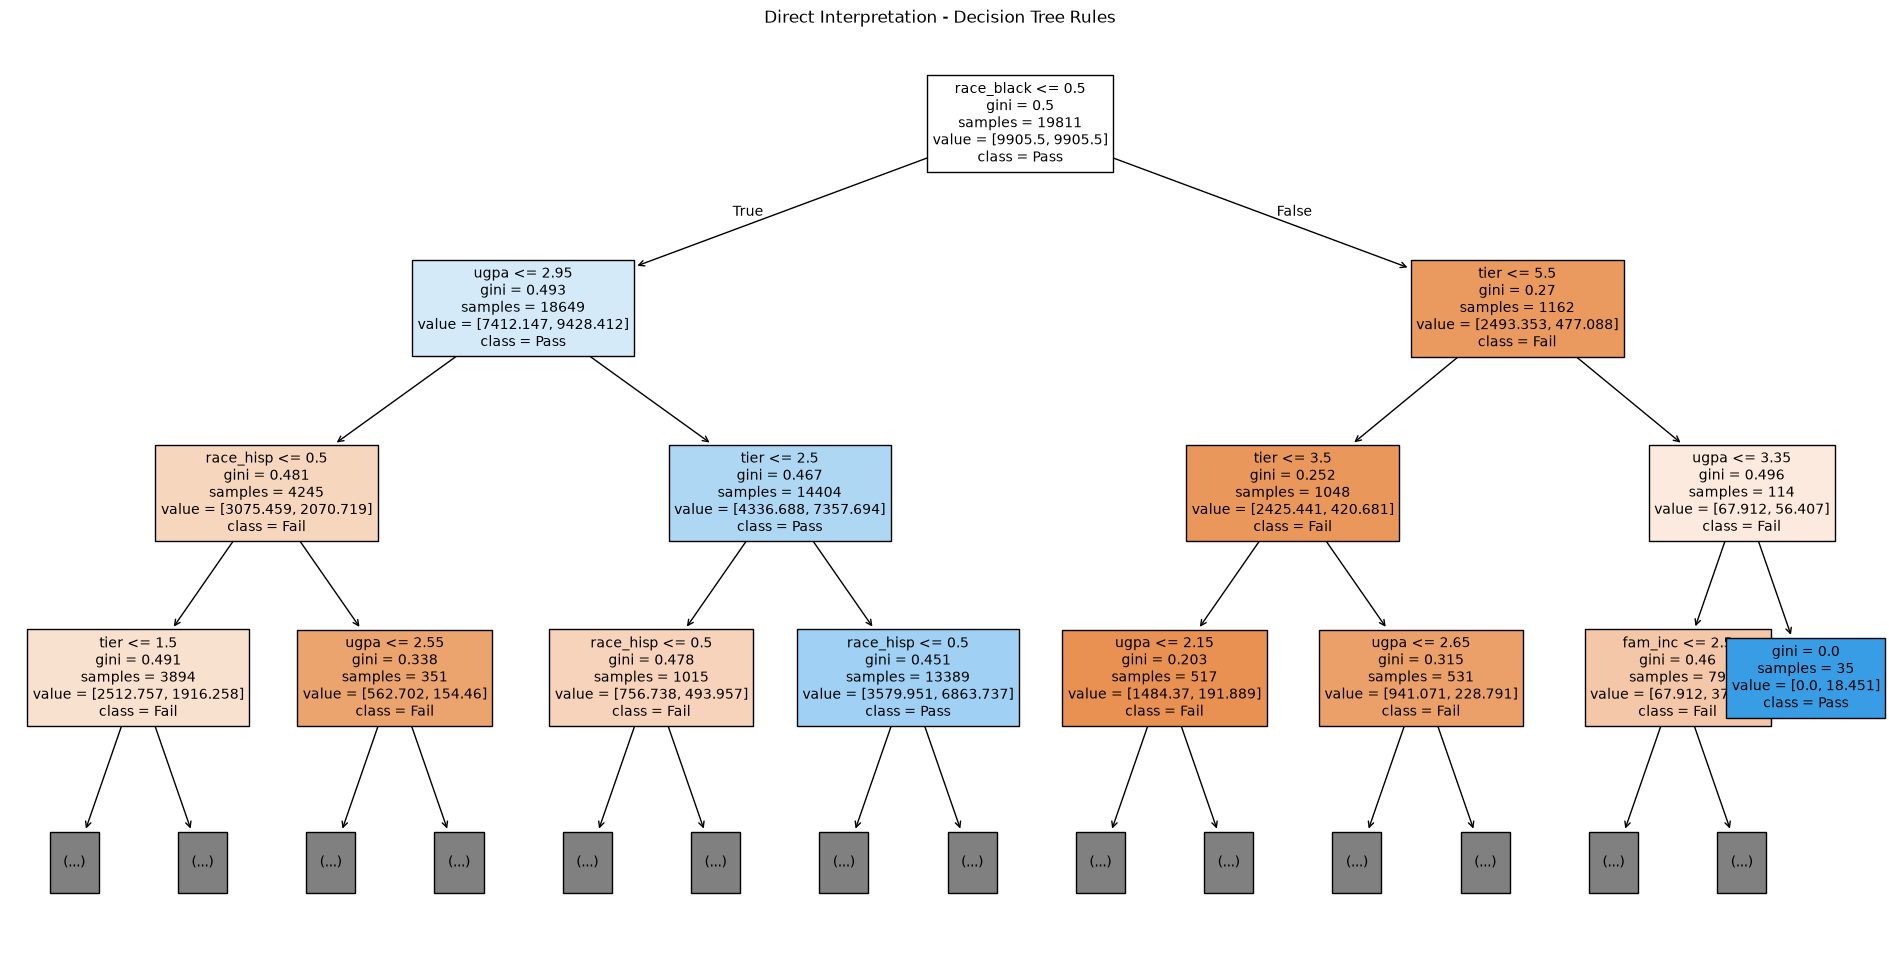

In [ ]:
dt_model = models["Decision Tree"][0]

tree_rules = export_text(dt_model, feature_names=feature_names)

print("=== Decision Tree Rules ===")
print(tree_rules)

plt.figure(figsize=(24, 12))
plot_tree(
    dt_model, 
    feature_names=X.columns, 
    class_names=["Fail", "Pass"], 
    filled=True, 
    max_depth=3, # Limiting depth for better readability
    fontsize=10
)
plt.title("Direct Interpretation - Decision Tree Rules")
plt.savefig("figures/decision_tree.png")
plt.show()

#### 3.1.2. Linear Regression

In [ ]:
lr_model = models["Logistic Regression"][0]

# 1. Extract the intercept (Beta 0)
intercept = lr_model.intercept_[0]
base_odds = np.exp(intercept)
base_probability = base_odds / (1 + base_odds)

# 2. Extract coefficients and pair them with feature names
coefficients = lr_model.coef_[0]

# 3. Create an interpretation summary DataFrame
interpretation_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient (Log-Odds)': coefficients,
    'Odds Ratio (e^coef)': np.exp(coefficients)
})

# 4. Calculate the percentage change in odds for intuitive reading
interpretation_df['Odds Change (%)'] = (interpretation_df['Odds Ratio (e^coef)'] - 1) * 100

# 5. Sort the features by their absolute impact to highlight the most important ones
interpretation_df['Abs_Impact'] = interpretation_df['Coefficient (Log-Odds)'].abs()
interpretation_df = interpretation_df.sort_values(by='Abs_Impact', ascending=False).drop(columns=['Abs_Impact'])

print("=== Baseline Model Metrics (All Features = 0) ===")
print(f"Intercept (Log-Odds): {intercept:.4f}")
print(f"Baseline Odds:        {base_odds:.4f}")
print(f"Baseline Probability: {base_probability * 100:.2f}%\n")

print("=== Feature Interpretation Table ===")
display(interpretation_df)

=== Baseline Model Metrics (All Features = 0) ===
Intercept (Log-Odds): 0.3505
Baseline Odds:        1.4198
Baseline Probability: 58.67%

=== Feature Interpretation Table ===


,Feature,Coefficient (Log-Odds),Odds Ratio (e^coef),Odds Change (%)
0,ugpa,0.391383,1.479024,47.902431
5,race_black,-0.372178,0.689232,-31.076812
3,tier,0.305846,1.357773,35.777266
6,race_hisp,-0.226955,0.796957,-20.304343
2,fam_inc,0.182319,1.199996,19.999641
4,race_asian,-0.175552,0.838994,-16.100592
7,race_other,-0.134432,0.874212,-12.578779
1,male,0.074624,1.077479,7.747946


### 3.2. Global Methods (Applied to Best Random Forest)

In [16]:
rf_model = models["Random Forest"][0]

# 1. Initialize the SHAP explainer specifically for Tree-based models (Random Forest)
shap_explainer = shap.TreeExplainer(rf_model)

#### 3.2.1. SHAP

--- SHAP Global Feature Importance ---


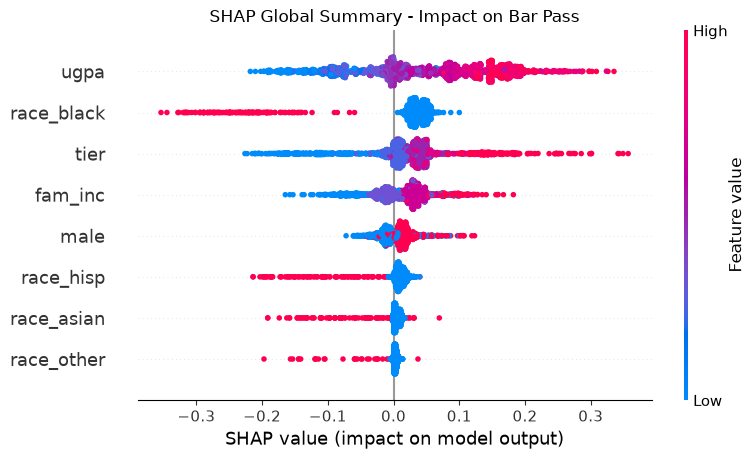

In [ ]:
# 2. Calculate SHAP values for the test dataset
shap_global_values = shap_explainer(X_test)

# Explanation object: [all_rows, all_features, class_1]
shap_global_values = shap_global_values[:, :, 1]

print("--- SHAP Global Feature Importance ---")

plt.figure(figsize=(10, 6))
plt.title("SHAP Global Summary - Impact on Bar Pass")

# Generate a beeswarm plot (dots representing individual cases)
shap.summary_plot(shap_global_values, X_test, feature_names=feature_names, show=False)

# Save the plot for your academic report
plt.savefig('figures/shap_global_summary.png', bbox_inches='tight', dpi=300)
plt.show()

#### 3.2.2. ELI5

In [141]:
print("--- Global Explanation with ELI5 ---")

print("\nELI5 weights:")
weights = eli5.explain_weights(rf_model, feature_names=feature_names)
print(eli5.format_as_text(weights, show=(
    'transition_features',
    'targets',
    'feature_importances',
    'decision_tree'
)))

print("\nELI5 permutations:")
perm = PermutationImportance(rf_model, random_state=42)
perm.fit(X_test, y_test)
perm_weights = eli5.explain_weights(perm, feature_names=feature_names)
print(eli5.format_as_text(perm_weights, show=(
    'transition_features',
    'targets',
    'feature_importances',
    'decision_tree'
)))

--- Global Explanation with ELI5 ---

ELI5 weights:
0.3463 ± 0.1081  ugpa
0.2265 ± 0.1326  race_black
0.1893 ± 0.0580  tier
0.1057 ± 0.0471  fam_inc
0.0548 ± 0.0302  race_hisp
0.0299 ± 0.0248  male
0.0271 ± 0.0183  race_asian
0.0205 ± 0.0116  race_other

ELI5 permutations:
0.0177 ± 0.0096  male
0.0167 ± 0.0118  ugpa
0.0086 ± 0.0066  race_black
0.0083 ± 0.0106  tier
0.0054 ± 0.0053  fam_inc
0.0002 ± 0.0042  race_hisp
-0.0002 ± 0.0031  race_asian
-0.0024 ± 0.0019  race_other


### 3.3. Local Methods (Applied to Best Random Forest)

#### 3.3.1. Get diversified examples

In [28]:
# Choose specific instances from the test set to explain
indexes = [44, 116, 1474]
X_manual = X_test.values[indexes]
y_manual = y_test.values[indexes]


for idx, record in enumerate(X_manual):
    print(f"\n--- Local Explanation for Case #{idx+1} ---")

    lime_predict = rf_model.predict([record])
    print(f"Expected: {y_manual[idx]} | Predicted: {lime_predict[0]}")
    print("\nValues of tested record:")
    print(pd.Series(record, index=feature_names))


--- Local Explanation for Case #1 ---
Expected: 1 | Predicted: 1

Values of tested record:
ugpa          3.1
male          0.0
fam_inc       3.0
tier          5.0
race_asian    0.0
race_black    0.0
race_hisp     0.0
race_other    0.0
dtype: float64

--- Local Explanation for Case #2 ---
Expected: 1 | Predicted: 0

Values of tested record:
ugpa          3.1
male          0.0
fam_inc       3.0
tier          5.0
race_asian    0.0
race_black    1.0
race_hisp     0.0
race_other    0.0
dtype: float64

--- Local Explanation for Case #3 ---
Expected: 1 | Predicted: 0

Values of tested record:
ugpa          3.7
male          0.0
fam_inc       4.0
tier          3.0
race_asian    0.0
race_black    1.0
race_hisp     0.0
race_other    0.0
dtype: float64


d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#### 3.3.2. SHAP

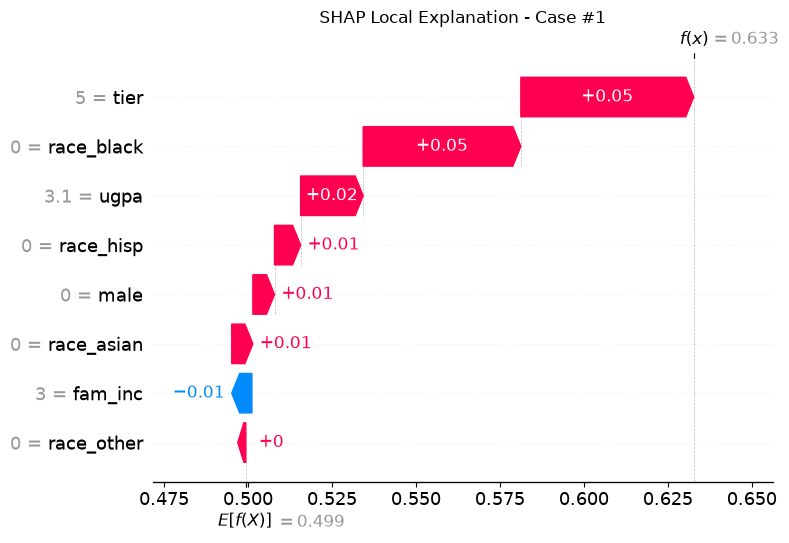

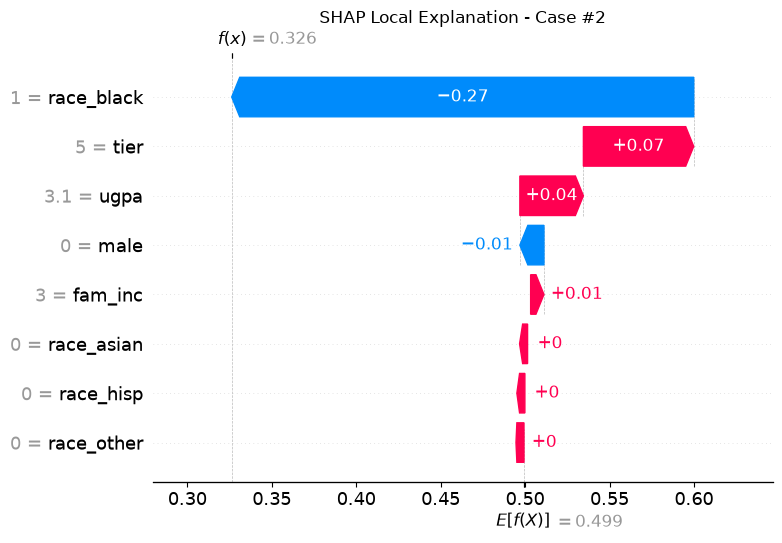

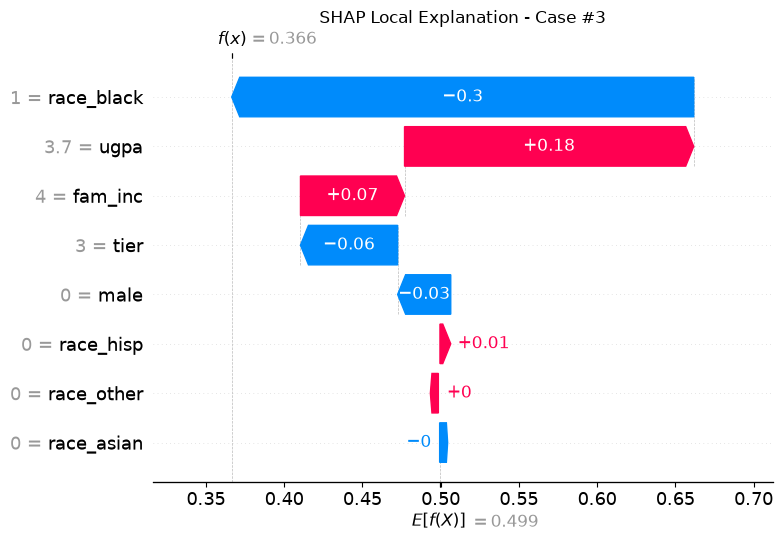

In [ ]:
shap_local_results = shap_explainer(X_manual)
shap_local_results = shap_local_results[:, :, 1]

for idx, result in enumerate(shap_local_results):
    result.feature_names = feature_names

    plt.figure(figsize=(8, 6))
    plt.title(f"SHAP Local Explanation - Case #{idx+1}")

    # Generate a waterfall plot showing how each feature pushed the prediction
    shap.plots.waterfall(result, show=False)

    plt.savefig(f'figures/shap_local_waterfall_{idx+1}.png', bbox_inches='tight', dpi=300)
    plt.show()

#### 3.3.3 LIME


--- LIME Local Explanation for Instance 0 ---


d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


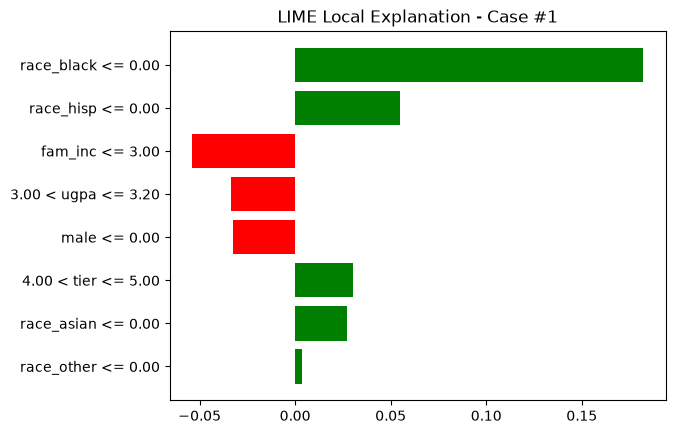


--- LIME Local Explanation for Instance 1 ---


d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


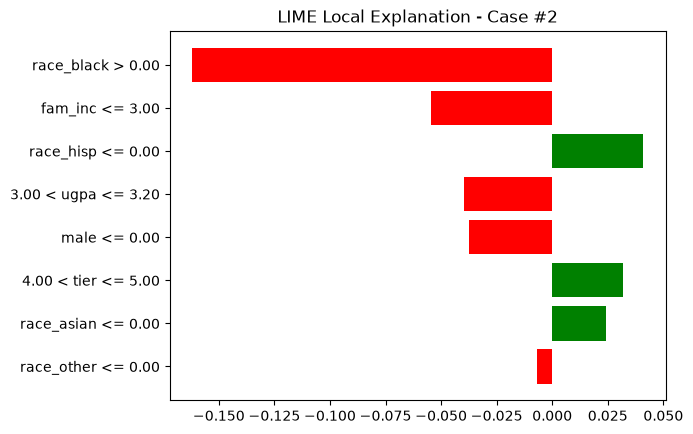


--- LIME Local Explanation for Instance 2 ---


d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


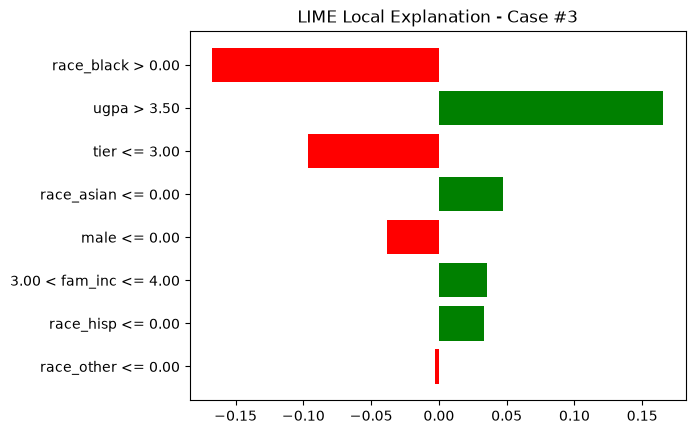

In [ ]:
# Initialize LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Fail', 'Pass'],
    mode='classification',
    random_state=42
)

for idx, record in enumerate(X_manual):
    print(f"\n--- LIME Local Explanation for Instance {idx} ---")
        
    lime_result = lime_explainer.explain_instance(
        data_row=record, 
        predict_fn=rf_model.predict_proba,
        num_features=10,
    )

    # Visualize the local explanation (this renders an HTML object in Jupyter)
    lime_result.as_pyplot_figure()
    plt.title(f"LIME Local Explanation - Case #{idx+1}")


    
    plt.savefig(f'figures/lime_local_waterfall_{idx+1}.png', bbox_inches='tight', dpi=300)
    plt.show()

#### 3.3.4. ELI5

In [29]:
for idx, record in enumerate(X_manual):
    print(f"\n--- ELI5 Local Explanation for Case #{idx+1} ---")
    
    eli5_result = eli5.explain_prediction(rf_model, record, feature_names=feature_names)
    
    print(eli5.format_as_text(eli5_result, show=(
    'transition_features',
    'targets',
    'feature_importances',
    'decision_tree'
)))


--- ELI5 Local Explanation for Case #1 ---
y=1 (probability=0.633) top features
Contribution  Feature   
------------  ----------
      +0.499  <BIAS>    
      +0.063  tier      
      +0.055  race_black
      +0.015  race_hisp 
      +0.009  race_asian
      +0.006  race_other
      -0.000  male      
      -0.007  fam_inc   
      -0.007  ugpa      


--- ELI5 Local Explanation for Case #2 ---
y=0 (probability=0.674) top features
Contribution  Feature   
------------  ----------
      +0.501  <BIAS>    
      +0.336  race_black
      +0.013  male      
      -0.001  race_other
      -0.001  race_asian
      -0.005  race_hisp 
      -0.023  fam_inc   
      -0.069  tier      
      -0.077  ugpa      


--- ELI5 Local Explanation for Case #3 ---
y=0 (probability=0.634) top features
Contribution  Feature   
------------  ----------
      +0.501  <BIAS>    
      +0.339  race_black
      +0.078  tier      
      +0.010  male      
      -0.001  race_other
      -0.001  race_asian
     

d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\diogo\Desktop\MsEx_IA_apl\Explicabilidade e Regulamentação\tp\torch-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
